In [3]:
import sys
sys.path.append("../src")
from data import get_datasets
from tensorflow import keras
import matplotlib.pyplot as plt

train_ds, val_ds, test_ds, class_names = get_datasets(img_size=(128, 128))
print(len(class_names), "classes")

Skipping bad file: ..\data\PlantVillage\Tomato__Tomato_YellowLeaf__Curl_Virus\svn-r6Yb5c
15 classes


In [4]:
model = keras.Sequential([
    keras.layers.Input(shape=(128, 128, 3)),
    keras.layers.RandomFlip("horizontal_and_vertical"),
    keras.layers.RandomRotation(0.1),
    keras.layers.Rescaling(1./255),
    keras.layers.Conv2D(32, 3, activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(128, 3, activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(len(class_names), activation="softmax"),
])
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,575 (12.61 MB)

 Trainable params: 3,306,575 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5


c:\Users\advai\Documents\plant-disease-detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


516/516 ━━━━━━━━━━━━━━━━━━━━ 67s 127ms/step - accuracy: 0.5763 - loss: 1.3025 - val_accuracy: 0.7117 - val_loss: 0.8672
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 59s 115ms/step - accuracy: 0.7842 - loss: 0.6336 - val_accuracy: 0.7737 - val_loss: 0.6770
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 60s 117ms/step - accuracy: 0.8365 - loss: 0.4808 - val_accuracy: 0.8517 - val_loss: 0.4415
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 63s 122ms/step - accuracy: 0.8660 - loss: 0.4053 - val_accuracy: 0.8018 - val_loss: 0.6702
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 64s 124ms/step - accuracy: 0.8847 - loss: 0.3428 - val_accuracy: 0.8212 - val_loss: 0.5682


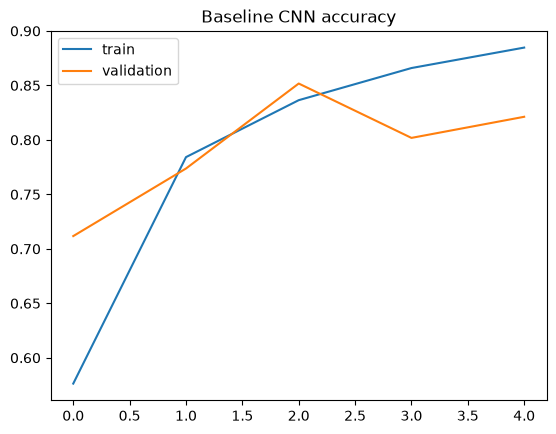

In [7]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.legend()
plt.title("Baseline CNN accuracy")
plt.show()

## Baseline results
- Small CNN trained from scratch, 5 epochs
- Train accuracy 88%, validation accuracy 82% (best 85% at epoch 3)
- Validation accuracy fluctuates between epochs, which suggests overfitting
- Next: transfer learning with MobileNetV2